## SETUP AND IMPORTS

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

In [9]:
# SIRD model (as in practical)
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Parameters:
    ----------------
    - y:Sequence of float
        Current compartment values [S,I,R,D]
    - t:float
        Current simulation time
    - beta: float
        Transmission rate
    - gamma: float
        Recovery rate
    -mu: float
        Mortality rate

    Returns
    ----------------
    tuple of float
        Derivatives(dS/dt, dI/dt, dR/dt, dD/dt)
    """
    S, I, R, D = y
    N = S + I + R + D

    dSdt = -beta*S*I/N
    dIdt = beta*S*I/N -gamma*I - mu*I
    dRdt = gamma*I
    dDdt = mu*I

    return dSdt, dIdt, dRdt, dDdt

## PART 1. PARAMETER ANALYSIS FUNCTION

In [12]:

def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here

    # Set the recovery rate values of interest
    gamma_values=[0.05, 0.1, 0.15, 0.2, 0.25]

    # Set initial conditions
    S0=N-I0
    R0_initial=0
    D0=0
    y0=[S0,I0,R0_initial, D0]

    # We create an array of daily output points
    t=np.arange(0, simulation_days +1)

    results=[]

    infection_curves={} # for plotting

    # Running model for different values of gamma and collecting the needed statistics
    for gamma in gamma_values:
        solution=odeint(sird_model, y0, t, args=(beta,gamma,mu))
        # extracting solution columns

        S=solution[:,0]
        I=solution[:,1]
        R=solution[:,2]
        D=solution[:,3]

        # Save infection curve for plotting
        infection_curves[gamma]=I
        # extracting the index of highest infections
        peak_idx=np.argmax(I)
        peak_infect=I[peak_idx]
        peak_day=t[peak_idx]
         # Epidemic duration:
        # first day after the peak when fewer than 1 infected individual remains
        below_one = np.where(I[peak_idx:] < 1)[0]

        if len(below_one) > 0:
            epidemic_duration = t[peak_idx + below_one[0]]
        else:
            epidemic_duration = simulation_days

        # Total deaths
        total_deaths=D[-1]
        # Basic reproduction number (as required in the assignment)
        basic_repr_num=beta/gamma
        results.append({
    "gamma": gamma,
    "R0": basic_repr_num,
    "peak_infected": peak_infect,
    "peak_day": peak_day,
    "epidemic_duration": epidemic_duration,
    "total_deaths": total_deaths})

    # Create results data frame
    results_df = pd.DataFrame(
    results,
    columns=[
        "gamma",
        "R0",
        "peak_infected",
        "peak_day",
        "epidemic_duration",
        "total_deaths"
    ])
    # formatting the results to ensure we get integer values
    results_df['peak_infected']=(results_df["peak_infected"].round().astype(int))
    results_df["total_deaths"]=(results_df["total_deaths"].round().astype(int))

    # defining a plotting function
    def plot_curves(ax=None, title=None):

        if ax is None:
            fig, ax= plt.subplots(figsize=(10,6))

        for gamma in gamma_values:
            I=infection_curves[gamma]
            R0_value=beta/gamma

        ax.plot(t, I, linewidth=2, label= f"$gamma\\$= {gamma:.2f}, $R_0$={R0_value:.2f}")
        ax.set_xlabel("Time in days", fontsize=12)
        ax.set_ylabel("Number of infected people", fontsize=12)
        if title is None:
            title="Recovery dynamics for SIRD model for different recovery rates"
        ax.set_title(title, fontsize=14, fontweight=15)
        ax.legend(title="Recovery rate")
        ax.grid(True, alpha=0.5)
        ax.set_xlim(0, simulation_days)
        ax.set_ylim(bottom=0)

        return ax

    return results_df, plot_curves



## PART 2: Scenario comparison

In [13]:
# Running the function on both scenarios and unpackin plotting function
scenario_A, plot_A =analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)
scenario_B, plot_B=analyze_recovery_rates(beta=0.2, mu=0.005,N=1000, I0=5, simulation_days=200 )

In [14]:
# Displaying both Data Frames
print("Scenario A")
display(scenario_A)
print("Scenario B")
display(scenario_B)

Scenario A


,gamma,R0,peak_infected,peak_day,epidemic_duration,total_deaths
0,0.05,8.000000,521,21,118,285
1,0.10,4.000000,340,22,86,160
2,0.15,2.666667,213,24,77,103
3,0.20,2.000000,124,27,78,67
4,0.25,1.600000,63,30,84,43


Scenario B


,gamma,R0,peak_infected,peak_day,epidemic_duration,total_deaths
0,0.05,4.000000,371,44,178,88
1,0.10,2.000000,139,52,154,37
2,0.15,1.333333,31,67,185,14
3,0.20,1.000000,5,0,116,2
4,0.25,0.800000,5,0,28,0


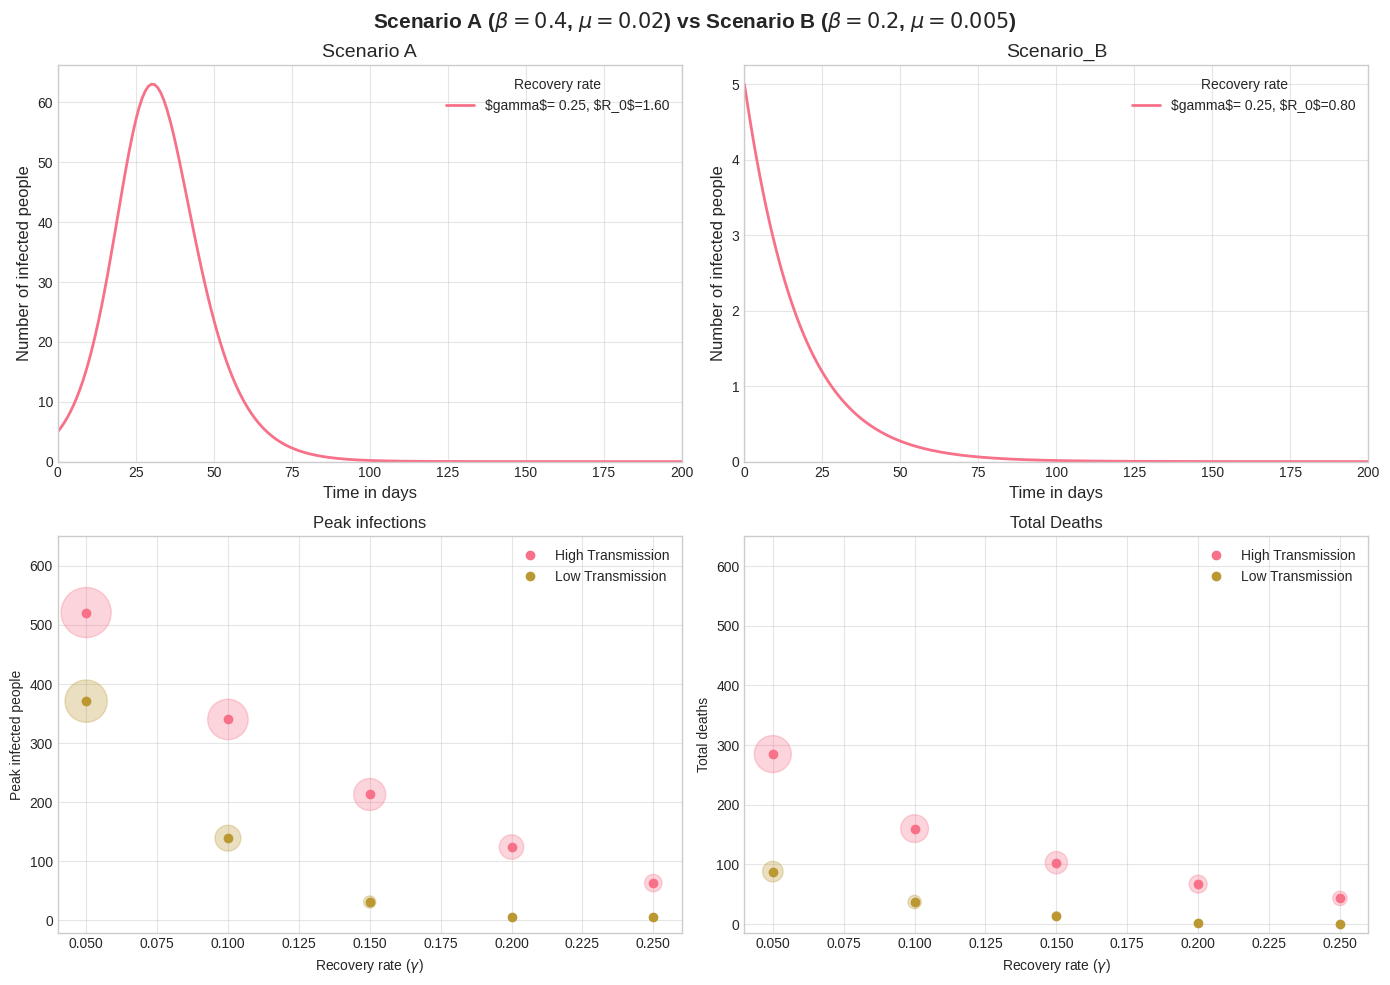

In [15]:
# Comparing both scenarios visually

fig, axes=plt.subplots(2,2, figsize=(14,10))
plot_A(ax=axes[0,0], title="Scenario A")
plot_B(ax=axes[0,1], title="Scenario_B")
axes[1,0].plot(scenario_A["gamma"], scenario_A["peak_infected"], 'o', linewidth=2, label="High Transmission")
axes[1,0].plot(scenario_B["gamma"], scenario_B["peak_infected"], 'o', linewidth=2, label="Low Transmission")

# In the bottom panel we basicaly plot the data points and overlay a scater plot with the radius proportional
# to the number of the category visualised, scaled by 2.5.

axes[1,0].scatter(
    scenario_A["gamma"],
    scenario_A["peak_infected"],
    s=scenario_A["peak_infected"] * 2.5,
    alpha=0.3
)
axes[1,0].scatter(
    scenario_B["gamma"],
    scenario_B["peak_infected"],
    s=scenario_B["peak_infected"] * 2.5,
    alpha=0.3
)
axes[1,0].set_xlabel(r"Recovery rate ($\gamma$)")
axes[1,0].set_ylabel("Peak infected people")
axes[1,0].set_title("Peak infections")
axes[1,0].set_ylim(top=650)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.5)

axes[1,1].plot(scenario_A["gamma"], scenario_A["total_deaths"], 'o', linewidth=2, label="High Transmission")
axes[1,1].plot(scenario_B["gamma"], scenario_B["total_deaths"], 'o', linewidth=2, label="Low Transmission")

axes[1,1].scatter(
    scenario_A["gamma"],
    scenario_A["total_deaths"],
    s=scenario_A["total_deaths"] * 2.5,
    alpha=0.3
)
axes[1,1].scatter(
    scenario_B["gamma"],
    scenario_B["total_deaths"],
    s=scenario_B["total_deaths"] * 2.5,
    alpha=0.3
)
axes[1,1].set_xlabel(r"Recovery rate ($\gamma$)")
axes[1,1].set_ylabel("Total deaths")
axes[1,1].set_title("Total Deaths")
axes[1,1].set_ylim(top=650)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.5)

plt.suptitle(
    r"Scenario A ($\beta=0.4$, $\mu=0.02$) vs "
    r"Scenario B ($\beta=0.2$, $\mu=0.005$)",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

### Public health comparison of Scenario A and Scenario B

Scenario A poses a greater public-health threat than Scenario B across all tested recovery rates. Scenario A has both a higher transmission rate ((beta=0.4) compared with (0.2)) and a higher mortality rate ((mu=0.02) compared with (0.005)). This is clearly reflected in both the epidemic peaks and the total number of deaths.

At the lowest recovery rate, (gamma=0.05), Scenario A reaches a peak of 521 infected individuals on day 21 and results in 285 deaths. Scenario B, under the same recovery rate, reaches a lower peak of 371 infected individuals on day 44 and results in 88 deaths. Scenario A therefore produces a larger epidemic that also develops considerably faster. From a public-health perspective, this rapid increase is especially problematic because a large number of people become infected simultaneously, potentially placing substantial pressure on healthcare capacity while leaving less time to respond.

The difference remains clear as the recovery rate increases. At (gamma=0.10), Scenario A reaches a peak of 340 infected individuals and produces 160 deaths, whereas Scenario B peaks at 139 infected individuals and produces only 37 deaths. At (gamma=0.15), Scenario A still reaches a peak of 213 infected individuals with 103 deaths, compared with only 31 peak infections and 14 deaths in Scenario B.

At the highest recovery rates, the difference becomes even more pronounced. In Scenario B, at (gamma=0.20) and (0.25), the maximum number of infected individuals remains equal to the initial five infected people and occurs on day 0. This indicates that the infected population starts declining immediately rather than developing into a growing epidemic. In contrast, Scenario A still produces epidemic peaks of 124 and 63 infected individuals respectively.

The assignment-defined basic reproduction number (R_0=beta &gamma) is also twice as high in Scenario A as in Scenario B for each corresponding recovery rate because the transmission rate is twice as large. For example, at (gamma=0.10), (R_0=4) in Scenario A compared with (R_0=2) in Scenario B.

Overall, Scenario A is clearly more dangerous to public health. It combines faster transmission with a higher mortality rate, resulting in larger and earlier epidemic peaks and substantially more deaths across every tested recovery rate. Scenario B shows that sufficiently high recovery rates can almost completely suppress epidemic growth under lower-transmission conditions.

## Policy Recommendations

### 3.1 Parameter impact analysis

Increasing the recovery rate \(gamma\) has a strong beneficial effect on epidemic severity in both scenarios. A higher recovery rate means that infected individuals leave the infected compartment more quickly. Consequently, they have less time to transmit the disease and spend less time exposed to the mortality process represented by \(mu\).

#### Impact on peak infections

In Scenario A, increasing \(gamma\) strongly reduces the epidemic peak. At \(gamma=0.05\), the epidemic reaches a peak of 521 infected individuals on day 21. At \(gamma=0.10\), the peak decreases to 340 infected individuals, a reduction of approximately 34.7%. Increasing \(gamma\) further to 0.25 reduces the peak to only 63 infected individuals, representing an overall reduction of approximately 87.9%.

The same relationship is visible in Scenario B. At \(gamma=0.05\), the peak is 371 infected individuals. This decreases to 139 at \(gamma=0.10\) and only 31 at \(gamma=0.15\). At \(gamma=0.20\) and \(0.25\), the maximum number of infected individuals remains equal to the initial five infected individuals and occurs on day 0. This means that, under these conditions, the infected population immediately starts declining rather than developing into a growing epidemic.

#### Impact on total deaths

Increasing the recovery rate also strongly reduces total deaths. In Scenario A, total deaths decrease from 285 at \(gamma=0.05\) to 43 at \(gamma=0.25\), a reduction of approximately 84.9%. This occurs for two reasons. First, infected individuals recover more quickly and therefore spend less time at risk of dying. Second, their shorter infectious period reduces onward transmission, indirectly preventing additional infections and subsequent deaths.

Scenario B shows the same pattern. Total deaths decrease from 88 at \(gamma=0.05\) to 37 at \(gamma=0.10\), 14 at \(gamma=0.15\), 2 at \(gamma=0.20\), and approximately 0 after rounding at \(gamma=0.25\).

#### Impact on epidemic duration

The effect of recovery rate on epidemic duration is more complex. We defined epidemic duration as the first day after the epidemic peak at which fewer than one infected individual remains in the deterministic model.

In Scenario A, the epidemic duration decreases from 118 days at \(gamma=0.05\) to 86 days at \(gamma=0.10\) and 77 days at \(gamma=0.15\). However, it then increases slightly to 78 days at \(gamma=0.20\) and 84 days at \(gamma=0.25\). Therefore, increasing the recovery rate does not produce a strictly monotonic reduction in epidemic duration, even though it consistently reduces epidemic size and mortality.

This non-linear pattern is even clearer in Scenario B. The epidemic lasts 178 days at \(gamma=0.05\), 154 days at \(gamma=0.10\), and 185 days at \(gamma=0.15\). At \(gamma=0.15\), the epidemic is much smaller, with only 31 individuals infected at its peak, but it develops slowly and peaks only on day 67. At \(gamma=0.20\), infections decline immediately and fall below one infected individual by day 116, while at \(gamma=0.25\) this occurs by day 28.

These results demonstrate that epidemic severity and epidemic duration are not the same outcome. Increasing \(gamma\) consistently reduces peak infections and deaths, but near the threshold between epidemic growth and decline, a small outbreak can persist for a relatively long time because infection numbers change only slowly.

Overall, increasing the recovery rate strongly improves public-health outcomes by reducing both peak infections and total deaths. Its effect on epidemic duration is more complex and depends on how close the system is to the threshold for sustained epidemic growth.


### 3.2 Intervention analysis

To estimate the effect of an intervention that increases the recovery rate by 50%, we use \(gamma=0.10\) in Scenario A as the baseline. This value is useful because a 50% increase gives another recovery rate that was already included in our simulations:

$$
\gamma_{\text{intervention}}
= 0.10 \times 1.50
= 0.15
$$

At the baseline recovery rate of \(gamma=0.10\), Scenario A results in 160 total deaths. After increasing the recovery rate by 50% to \(gamma=0.15\), total deaths decrease to 103.

The absolute reduction in deaths is therefore:

$$
160-103=57 \text{ fewer deaths}
$$

The relative reduction is:

$$
\frac{160-103}{160}\times100
\approx35.6\%
$$

According to the SIRD model, a 50% increase in the recovery rate therefore reduces total deaths from 160 to 103, corresponding to approximately 57 fewer deaths or a 35.6% reduction.

The decrease in deaths is smaller than the 50% increase in recovery rate because the relationship between model parameters and epidemic outcomes is not linear. Increasing \(gamma\) changes the epidemic dynamics by moving infected individuals into the recovered compartment more quickly, which both reduces their time at risk of death and limits further transmission.

###3.3 Policy Recommendations
#### Medical intervention

One real medical intervention is; Paxlovid, Paxlovid is an antiviral treatment that inhibits SARS-CoV-2 replication (is given to a patient when infected). By lowering viral replication, it can reduce the duration and severity of infection and substantially reduce the probability of hospitalization or death in high-risk patients. In a SIRD model, this can be represented by an increased recovery rate (gamma) and, a reduced mortality rate (mu). Clinical trials in high-risk unvaccinated patients found an approximately 86% relative reduction in hospitalization or death when treatment was started within five days of symptom onset. source: https://www.fda.gov/news-events/press-announcements/fda-approves-first-oral-antiviral-treatment-covid-19-adults

####Mechanism and realistic effectiveness

Paxlovid is an antiviral drug that inhibits a SARS-CoV-2 protease needed for viral replication. By reducing viral replication, it helps the body control the infection and can reduce disease severity. In a SIRD model, this could be represented by a somewhat higher recovery rate (gamma) and a lower mortality rate (mu). A realistic model assumption might be a small-to-moderate increase in (gamma), for example 5–10%, because clinical studies show only a modest effect on symptom duration. Its effect on severe outcomes is much stronger: in high-risk untreated/unvaccinated patients, early trials found roughly an 85–90% reduction in hospitalization or death.